# Transaction curation and internal joins

## Purpose and scope
Prepare one reliable row per order for downstream BNPL merchant analysis. This notebook reports the actual full-data run, cleaning decisions, internal join coverage, amount outliers and limitations. It does not rank merchants or label fraud. Census is curated separately and is not joined to this transaction output.

The cleaning implementation in `src/` is unchanged. Raw data are read only. This summary expands the submitted notebook with additional evidence from the saved transaction output.

## Inputs and reproducible workflow

| Input | Role | Join key |
|---|---|---|
| Three transaction snapshots | Orders, dates, amounts and merchant references | `order_id` identifies orders; `user_id`, `merchant_abn` link dimensions |
| `consumer_user_details.parquet` | Map users to consumers | `user_id` |
| `tbl_consumer.csv` | Consumer state, postcode and gender | `consumer_id` |
| `tbl_merchants.parquet` | Merchant names and tags | `merchant_abn` |

Dimension keys must be unique and non-null before joining. User and consumer joins must preserve accepted transaction counts or the pipeline fails. Merchant information is attached with a LEFT JOIN.

Run the pipeline from the module root after placing all input tables and snapshot directories below one input folder:

```bash
python -m src.run_pipeline --data-root /path/to/tables --output-root data/curated
python -m pytest -q
python curation_summary/build_analysis.py --merchant-master /path/to/tables/tbl_merchants.parquet
```

Then run this notebook from `curation_summary/`. It reads compact aggregate reports, so displaying it does not require loading 14 million transactions into pandas. `analysis_results/abn_diagnostic.csv` requires the optional merchant-master input; it records checks on the supplied master only.

## Cleaning rules

| Check | Decision |
|---|---|
| Order, user and merchant keys | Trim text; quarantine missing required transaction keys |
| Transaction date and amount | Parse date; quarantine invalid dates, nonfinite amounts and amounts ≤ 0 |
| Duplicate orders | Retain one exact duplicate; quarantine all records for conflicting order IDs |
| Consumer postcode | Trim and pad 1–4 digits to four characters; invalid format becomes null with a validity flag |
| Consumer demographics | Standardise state and gender text; omit names and addresses from output |
| Missing merchant master | Retain transaction; `merchant_master_matched = false` |
| High amounts | Flag values above the global p99; retain original values |

No quarantine records in this run means that none triggered the implemented rejection rules. It does not establish that every field is complete or that all transactions are legitimate.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_colwidth', 100)
data = Path('../data/curated')
analysis = Path('analysis_results')
audit = pd.read_csv(data/'curation_audit.csv')
join_coverage = pd.read_csv(data/'join_coverage.csv')
snapshot_coverage = pd.read_csv(data/'snapshot_coverage.csv')
merchant_exceptions = pd.read_csv(data/'merchant_match_exceptions.csv', dtype={'merchant_abn': 'string'})
data_quality_profile = pd.read_csv(data/'data_quality_profile.csv')
amount = pd.read_csv(analysis/'amount_summary.csv').iloc[0]
impact = pd.read_csv(analysis/'merchant_match_impact.csv')
display(pd.DataFrame({'metric':['Input transactions','Curated transactions','Unique order IDs','Quarantined rows'], 'value':[int(audit.iloc[0].input_rows),int(amount['rows']),int(amount.unique_orders),int(audit.quarantined_rows.sum())]}))
assert int(amount['rows']) == int(amount.unique_orders)
assert int(amount['rows']) == int(audit.iloc[-1].output_rows)

,metric,value
0,Input transactions,14195505
1,Curated transactions,14195505
2,Unique order IDs,14195505
3,Quarantined rows,0


## 1. What happened to the transactions?

The audit makes each cleaning decision visible. Transactions are quarantined only for invalid keys, dates or amounts, or for duplicate-order conflicts; high-value transactions are flagged rather than deleted.

,stage,input_rows,output_rows,quarantined_rows,removed_pct_of_input,notes
0,raw_transaction_partitions,14195505,14195505,0,0.0,All discovered transaction snapshot partitions; coverage is recorded separately.
1,basic_validation,14195505,14195505,0,0.0,"Missing keys, invalid dates, and non-positive or non-finite amounts are quarantined."
2,duplicate_order_resolution,14195505,14195505,0,0.0,One exact duplicate is retained; all conflicting duplicate order IDs are quarantined.
3,consumer_internal_joins,14195505,14195505,0,0.0,Inner joins are required to preserve row count or the run fails.
4,merchant_left_join_and_output,14195505,14195505,0,0.0,Unmatched merchants are retained with merchant_master_matched = false.


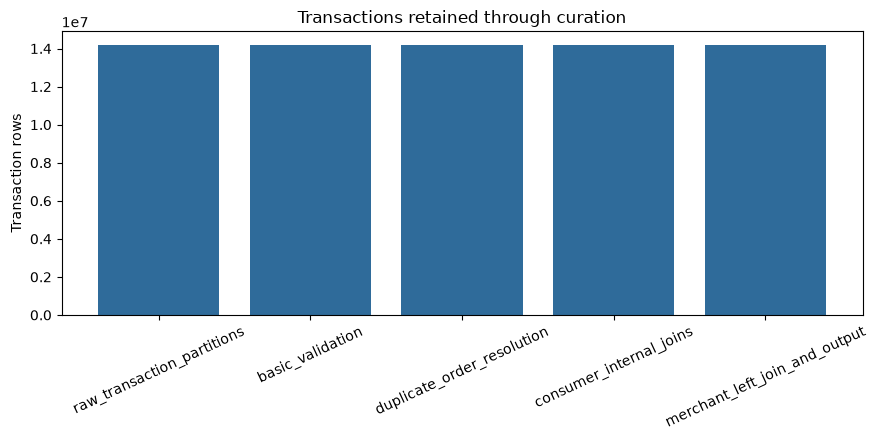

In [2]:
display(audit)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(audit['stage'], audit['output_rows'], color='#2F6B9A')
ax.set(title='Transactions retained through curation', ylabel='Transaction rows')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

## 2. Are the internal joins safe?

User and consumer joins are required to preserve the transaction row count. The merchant join is deliberately a left join: missing merchant-master records are retained for follow-up rather than removed from merchant-performance analysis.

Unmatched merchant ABNs: 396
Transactions retained with an unmatched merchant: 580,830


,join_name,input_rows,matched_rows,unmatched_rows,match_rate
0,transactions_to_user_mapping,14195505,14195505,0,1.000000
1,user_mapping_to_consumers,14195505,14195505,0,1.000000
2,transactions_to_merchants,14195505,13614675,580830,0.959084


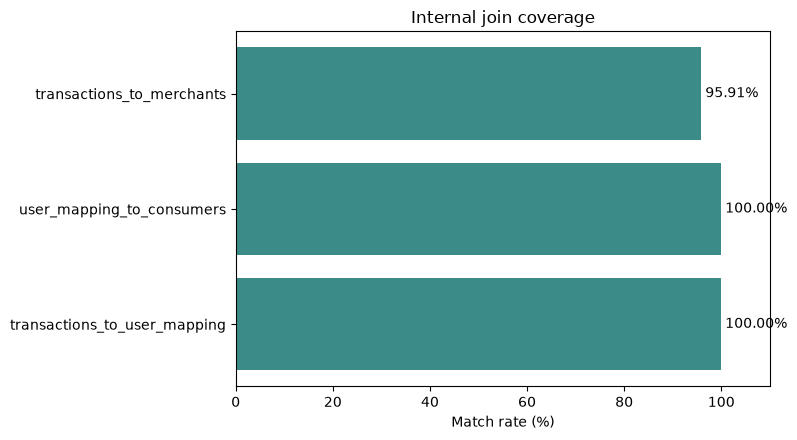

In [3]:
display(join_coverage)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(join_coverage['join_name'], join_coverage['match_rate'] * 100, color='#3B8C88')
ax.set(xlim=(0, 110), xlabel='Match rate (%)', title='Internal join coverage')
for index, value in enumerate(join_coverage['match_rate'] * 100):
    ax.text(value + 0.8, index, f'{value:.2f}%', va='center')
fig.tight_layout()
plt.show()

print(f"Unmatched merchant ABNs: {len(merchant_exceptions):,}")
print(f"Transactions retained with an unmatched merchant: {merchant_exceptions['transaction_count'].sum():,}")

## 3. What is the real timeline?

Snapshot folder names are not treated as authoritative. This table derives each snapshot's actual coverage from its daily transaction partitions, which is the date basis passed to downstream fraud, ABS and ranking work.

In [4]:
display(snapshot_coverage)

top_exceptions = merchant_exceptions.nlargest(10, 'transaction_count')
display(top_exceptions)

,source_snapshot,transaction_count,first_order_datetime,last_order_datetime
0,transactions_20210228_20210827_snapshot,3643266,2021-02-28,2021-08-27
1,transactions_20210828_20220227_snapshot,4508106,2021-08-28,2022-02-27
2,transactions_20220228_20220828_snapshot,6044133,2022-02-28,2022-10-26


,merchant_abn,transaction_count,total_dollar_value,first_order_datetime,last_order_datetime
0,32234779638,116773,8.745124e+06,2021-02-28,2022-10-26
1,11240426404,54716,7.002466e+06,2021-02-28,2022-10-26
2,33604812025,39419,8.458365e+06,2021-02-28,2022-10-26
3,29323795999,33100,1.365642e+06,2021-02-28,2022-10-26
4,20562405782,26972,2.817859e+06,2021-02-28,2022-10-26
5,67202032418,25504,6.847857e+06,2021-02-28,2022-10-26
6,29566626791,24260,1.206349e+06,2021-02-28,2022-10-26
7,91848160033,18523,5.109180e+05,2021-02-28,2022-10-26
8,79953723663,13012,1.013359e+06,2021-02-28,2022-10-26
9,74648589246,12262,7.728416e+06,2021-02-28,2022-10-26


## 4. Amount distribution and outlier treatment

The global 99th percentile is a review threshold, not a fraud label. Amounts above it remain in the output. No trimming, winsorisation or imputation was applied, so no deletion-based before/after comparison is appropriate.

The histogram uses log10(1 + AUD amount) bins to show the full right tail without dropping large transactions. Tick labels display AUD values. The threshold and counts are calculated from the full saved dataset, not a sample.

p99 = AUD 1,619.27; flagged 141,956 transactions (1.00%), accounting for 20.94% of recorded transaction value.


,value
rows,1.419550e+07
unique_orders,1.419550e+07
minimum,9.756658e-08
median,6.223040e+01
p95,5.905171e+02
p99,1.619273e+03
maximum,1.051939e+05
total_value,2.359704e+09
flagged_rows,1.419560e+05
flagged_value,4.942380e+08


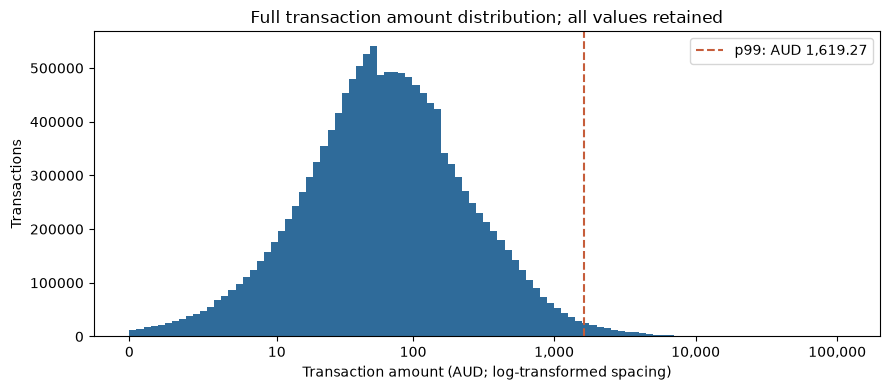

,is_amount_above_p99,transaction_count,minimum,maximum,transaction_value
0,False,14053549,9.756658e-08,1619.267676,1.865466e+09
1,True,141956,1.619273e+03,105193.885789,4.942380e+08


In [5]:
display(amount.to_frame('value'))
flagged_share = amount.flagged_rows / amount['rows']
flagged_value_share = amount.flagged_value / amount.total_value
print(f"p99 = AUD {amount.p99:,.2f}; flagged {int(amount.flagged_rows):,} transactions ({flagged_share:.2%}), accounting for {flagged_value_share:.2%} of recorded transaction value.")
hist = pd.read_csv(analysis/'amount_histogram.csv')
import numpy as np
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(hist.log10_amount_bin, hist.transaction_count, width=0.05, align='edge', color='#2F6B9A')
ax.axvline(np.log10(1+amount.p99),color='#C65D3B',linestyle='--',label=f'p99: AUD {amount.p99:,.2f}')
ticks=[0,10,100,1000,10000,100000,1000000]
ticks=[t for t in ticks if t <= amount.maximum*1.2]
ax.set_xticks(np.log10(1+np.array(ticks)),[f'{t:,}' for t in ticks])
ax.set(xlabel='Transaction amount (AUD; log-transformed spacing)',ylabel='Transactions',title='Full transaction amount distribution; all values retained')
ax.legend();fig.tight_layout();plt.show()
display(pd.read_csv(analysis/'amount_flag_groups.csv'))

**Observed result:** the p99 threshold is **AUD 1,619.27**. The **141,956** flagged transactions represent about **1.00%** of rows but **20.94%** of recorded value. The maximum is about **AUD 105,193.89**, compared with a median of **AUD 62.23**. This supports reviewing the right tail rather than deleting it mechanically.

High spending can be legitimate, and absolute amounts vary by merchant category. A global p99 alone cannot distinguish mistakes from genuine purchases or fraud. Downstream work should inspect category-specific distributions and fraud evidence. For historical predictive evaluation, thresholds should be estimated on training-period data to avoid using future observations.

## 5. Merchant non-match impact and diagnosis

The number of affected transaction rows is not the number of missing merchants or missing cells. One absent merchant can generate many transactions. The following report compares both transaction-count and recorded transaction-value coverage. Recorded transaction value is not BNPL revenue or profit.

In [6]:
display(impact)
unmatched = impact[impact.merchant_master_matched.eq(False)].iloc[0]
print(f"{int(unmatched.merchants):,} unmatched merchant ABNs; {int(unmatched.transaction_count):,} transactions ({unmatched.row_share:.2%}); AUD {unmatched.transaction_value:,.2f} ({unmatched.value_share:.2%} of transaction value).")
assert int(unmatched.transaction_count) == int(merchant_exceptions.transaction_count.sum())
diag_path = analysis/'abn_diagnostic.csv'
if diag_path.exists():
    display(pd.read_csv(diag_path))
else:
    print('ABN diagnosis not run: supply the original merchant master to build_analysis.py.')

396 unmatched merchant ABNs; 580,830 transactions (4.09%); AUD 202,648,153.74 (8.59% of transaction value).


,merchant_master_matched,transaction_count,merchants,transaction_value,row_share,value_share
0,True,13614675,4026,2.157056e+09,0.959084,0.914121
1,False,580830,396,2.026482e+08,0.040916,0.085879


,unmatched_abns,eleven_digit_abns,exact_master_matches,numeric_master_matches
0,396,396,0,0


**Observed result:** all 396 unmatched ABNs are 11-digit strings. None match the supplied merchant master after trimming or numeric conversion. Simple whitespace or numeric/text representation changes do not recover these matches. They account for **4.09% of transactions but 8.59% of recorded transaction value (about AUD 202.65 million)**, so count coverage alone understates their financial weight.

The ABN diagnostic checks trimmed text matching, 11-digit formatting and matching after numeric conversion. These checks assess simple representation differences; an 11-digit string does not certify a valid registered ABN. A missing match in the supplied master does not explain why the source omits the merchant, and is not evidence of fraud.

Retain these transactions for ABN-level activity summaries. Do not impute another merchant's name, category or fee. Confirm the ranking candidate universe and required scoring fields with the group/tutor before excluding any ABNs: the specification requests ranking all merchants. Report missing-information flags and coverage with downstream rankings.

## 6. Missingness and pending enrichment

Missingness in output fields, quarantine decisions and sources not yet integrated are different concepts. An empty quarantine does not imply zero missing fields. Counts below measure affected rows separately for each field; do not add them as if they were distinct transactions.

In [7]:
field_missing = data_quality_profile[data_quality_profile.classification.eq('field_missing_after_curation')]
display(field_missing[['field_or_metric','row_count','rate_of_curated_rows']])
raw_issues = data_quality_profile[data_quality_profile.classification.eq('raw_invalid_or_missing')]
if raw_issues.empty:
    print('No raw records were quarantined under the implemented rules in this run.')
else:
    display(raw_issues)
display(data_quality_profile[data_quality_profile.classification.eq('join_induced_unmatched')])
display(data_quality_profile[data_quality_profile.classification.eq('not_integrated_not_a_missing_value')])

No raw records were quarantined under the implemented rules in this run.


,field_or_metric,row_count,rate_of_curated_rows
0,order_id,0,0.000000
1,order_datetime,0,0.000000
2,user_id,0,0.000000
3,consumer_id,0,0.000000
4,merchant_abn,0,0.000000
5,dollar_value,0,0.000000
6,consumer_state,0,0.000000
7,consumer_postcode,0,0.000000
8,consumer_postcode_valid,0,0.000000
9,consumer_gender,0,0.000000


,stage,classification,field_or_metric,row_count,rate_of_curated_rows,treatment,notes
17,merchant_left_join,join_induced_unmatched,merchant_master_matched = false,580830,0.040916,Retain the transaction and use the match flag in coverage decisions.,The merchant ABN existed in the transaction but was absent from the merchant master.


,stage,classification,field_or_metric,row_count,rate_of_curated_rows,treatment,notes
18,pending_enrichment,not_integrated_not_a_missing_value,consumer_fraud_probability,14195505,1.0,Do not impute or default to zero at this stage.,"Join only after validating keys, time coverage and one-to-one cardinality."
19,pending_enrichment,not_integrated_not_a_missing_value,merchant_fraud_probability,14195505,1.0,Do not impute or default to zero at this stage.,"Join only after validating keys, time coverage and one-to-one cardinality."
20,pending_enrichment,not_integrated_not_a_missing_value,external_geographic_features,14195505,1.0,Do not impute or default to zero at this stage.,Join through a validated consumer-to-geography correspondence table.


Consumer/merchant fraud probabilities and Census features have not been attached to this fact table. Their pending status is not an observed null rate after an attempted join and must never be interpreted as zero fraud probability. The separately cleaned Census table has its own consumer-level coverage report; that rate must not be presented as transaction-weighted coverage.

## 7. Outputs, validation and handoff

- `data/curated/curated_transactions/`: one row per order, partitioned by year/month. Read the whole directory.
- Audit, quarantine, join coverage, snapshot coverage, merchant exceptions, field-quality profile and metadata are stored beside it.
- `analysis_results/`: aggregate amount distributions, outlier impact, merchant coverage and optional ABN diagnostics generated for this summary.
- Source `src/` and existing tests remain unchanged. Four existing tests passed during the original full-data run; this update separately verifies saved-output counts, uniqueness, report reconciliation and notebook execution.

Retained fields include `order_id`, `user_id`, `consumer_id`, `merchant_abn`, date, amount, consumer state/postcode/gender, merchant name/tags, snapshot, match flag and amount flag. Names and addresses of consumers are excluded, but remaining IDs are still linkable and should be handled as project data.

Fraud enrichment must validate its actual keys and time granularity before joining. Census can join on normalised `consumer_postcode` to a unique `postcode` dimension using a many-to-one LEFT JOIN. Check row preservation and report both row- and value-weighted coverage after each enrichment.

### Limitations and next steps

1. Source tables are synthetic; findings do not establish real-world consumer or merchant behaviour.
2. The merchant master is incomplete relative to observed transaction ABNs; the underlying cause remains unconfirmed.
3. A valid postcode format does not prove geographic validity or availability in Census.
4. Recorded dates are used; snapshot names are not authoritative. The code casts to DATE, so time-of-day is not retained.
5. No fraud classification, final merchant scoring or full external enrichment is completed by this module.
6. Census 2021 values are area context, not individual facts. Historical models must respect when external information became available.

These outputs support later feature engineering and ranking; data-quality flags should inform review, not automatically become a fraud label or a zero ranking score.